# Fast MultipoleExpansion Builds

This notebook demonstrates the three ways to build a `MultipoleExpansion`,
when to use each, and the speedups you get.

| Method | Best for | Speedup |
|--------|----------|--------:|
| `from_density(rho, ...)` | Any density function, one-off use | 1x |
| `grid(rho)` | Rapid iteration with arbitrary density functions | ~5-10x |
| `grid.from_values(arr)` | Sweeping parameters of a known density | ~17x |
| `from_spheroid(...)` | Agama-style spheroid profiles specifically | ~10-20x |

In [1]:
import time
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bfeax import MultipoleExpansion, SpheroidDensity, ExpansionGrid

## 1.`from_density`

Pass any callable `rho(x, y, z)`. Simple, but the full pipeline (density eval +
angular projection + Poisson solve + spline fitting) is JIT-compiled as one unit.
**Changing `rho` triggers a full recompilation.**

In [3]:
def nfw_density(x, y, z, rs=10.0, q=0.5):
    """Oblate NFW with axis ratio q."""
    r_tilde = jnp.sqrt(x**2 + y**2 + (z / q)**2)
    s = r_tilde / rs
    return 1.0 / (s * (1.0 + s)**2)

grid_kw = dict(r_min=1e-2, r_max=300.0, n_r=128, l_max=8)

# First call includes JIT compilation
rho_fn = lambda x, y, z: nfw_density(x, y, z, rs=10.0, q=0.5)
exp_ref = MultipoleExpansion.from_density(rho_fn, **grid_kw)

# Time a rebuild with different parameters
rho_fn2 = lambda x, y, z: nfw_density(x, y, z, rs=15.0, q=0.7)
t0 = time.perf_counter()
exp2 = MultipoleExpansion.from_density(rho_fn2, **grid_kw)
t1 = time.perf_counter()
print(f"from_density with new params: {(t1-t0)*1e3:.0f} ms")
print("  (includes JIT recompilation because rho changed)")

from_density with new params: 45 ms
  (includes JIT recompilation because rho changed)


In [4]:
@jax.jit
def evalforce(xyz,q):
    x,y,z = xyz
    dens_func = lambda x, y, z: nfw_density(x, y, z, rs=10.0, q=q)
    exp = MultipoleExpansion.from_density(dens_func, **grid_kw,prune_modes=False)
    return exp.force(x, y, z)

xyz = jnp.array([1.0,2.0,3.0])
q = 0.5
force = evalforce(xyz, q)
print(force)

(Array(-5.34043254, dtype=float64), Array(-10.68086507, dtype=float64), Array(-27.57404856, dtype=float64))


In [5]:
%timeit force = jax.block_until_ready(evalforce(xyz, q))


10.1 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [6]:
xyz_stack = jnp.stack([xyz, xyz**2, xyz*3], axis=0)
qs = jnp.linspace(0.5,1.2,5)
jax.vmap(evalforce,in_axes=(None,0))(xyz,qs)

(Array([ -5.34043254,  -7.34184876,  -9.31044219, -11.20157503,
        -12.98863676], dtype=float64),
 Array([-10.68086507, -14.68369753, -18.62088438, -22.40315005,
        -25.97727353], dtype=float64),
 Array([-27.57404856, -30.73464813, -32.28918411, -32.84700728,
        -32.79022235], dtype=float64))

## 2. The fast general way: `ExpansionGrid`

`ExpansionGrid` precomputes the angular quadrature grid and Y_lm values once.
It separates density evaluation from the build pipeline, so the build
**never recompiles** when the density changes.

In [7]:
# Create the grid once
grid = ExpansionGrid(**grid_kw)

print(f"Grid points: x shape = {grid.x.shape}")
print(f"  n_r={grid.x.shape[0]}, n_theta={grid.x.shape[1]}, n_phi={grid.x.shape[2]}")
print(f"  Total density evals per build: {np.prod(grid.x.shape)}")

Grid points: x shape = (128, 10, 17)
  n_r=128, n_theta=10, n_phi=17
  Total density evals per build: 21760


### 2a. `grid(rho)` — pass a density function

The grid evaluates your density on its precomputed points, then runs the
cached build pipeline. Convenient, and the build part never recompiles.

In [8]:
# Warmup
_ = grid(rho_fn)

# Now time it with a different density
t0 = time.perf_counter()
exp_grid = grid(rho_fn2)
t1 = time.perf_counter()
print(f"grid(rho) with new params: {(t1-t0)*1e3:.0f} ms")

grid(rho) with new params: 13 ms


### 2b. `grid.from_values(arr)` — pass precomputed density values

The fastest path. You evaluate the density yourself (however you want)
and pass the result as an `(n_r, n_theta, n_phi)` array. The grid
coordinates are available as `grid.x`, `grid.y`, `grid.z`.

In [9]:
# Evaluate density yourself (vectorised — no vmap needed)
rho_vals = nfw_density(grid.x, grid.y, grid.z, rs=15.0, q=0.7)
print(f"Density array shape: {rho_vals.shape}")

# Build from values
t0 = time.perf_counter()
exp_fv = grid.from_values(rho_vals)
t1 = time.perf_counter()
print(f"from_values: {(t1-t0)*1e3:.0f} ms  (build pipeline only)")

Density array shape: (128, 10, 17)
from_values: 3 ms  (build pipeline only)


### Verify they all agree

In [10]:
key = jax.random.PRNGKey(0)
test_pts = jax.random.uniform(key, (3, 5000), minval=-40.0, maxval=40.0)
tx, ty, tz = test_pts

phi_ref  = exp2(tx, ty, tz)         # from_density
phi_grid = exp_grid(tx, ty, tz)     # grid(rho)
phi_fv   = exp_fv(tx, ty, tz)       # from_values

for label, phi_test in [("grid(rho)", phi_grid), ("from_values", phi_fv)]:
    err = jnp.abs(phi_test - phi_ref) / (jnp.abs(phi_ref) + 1e-300)
    print(f"  {label:15s} vs from_density:  max err = {float(err.max()):.1e}")

  grid(rho)       vs from_density:  max err = 0.0e+00
  from_values     vs from_density:  max err = 0.0e+00


## 3. Parameter sweep: scanning axis ratio q

Practical use case: sweep over the flattening parameter of an NFW halo
and plot how the potential changes.

In [11]:
q_values = np.linspace(0.3, 1.0, 15)
expansions = []

t0 = time.perf_counter()
for q in q_values:
    rho_vals = nfw_density(grid.x, grid.y, grid.z, rs=10.0, q=float(q))
    expansions.append(grid.from_values(rho_vals))
t1 = time.perf_counter()
print(f"Built {len(q_values)} expansions in {(t1-t0)*1e3:.0f} ms "
      f"({(t1-t0)*1e3/len(q_values):.0f} ms each)")

Built 15 expansions in 292 ms (19 ms each)


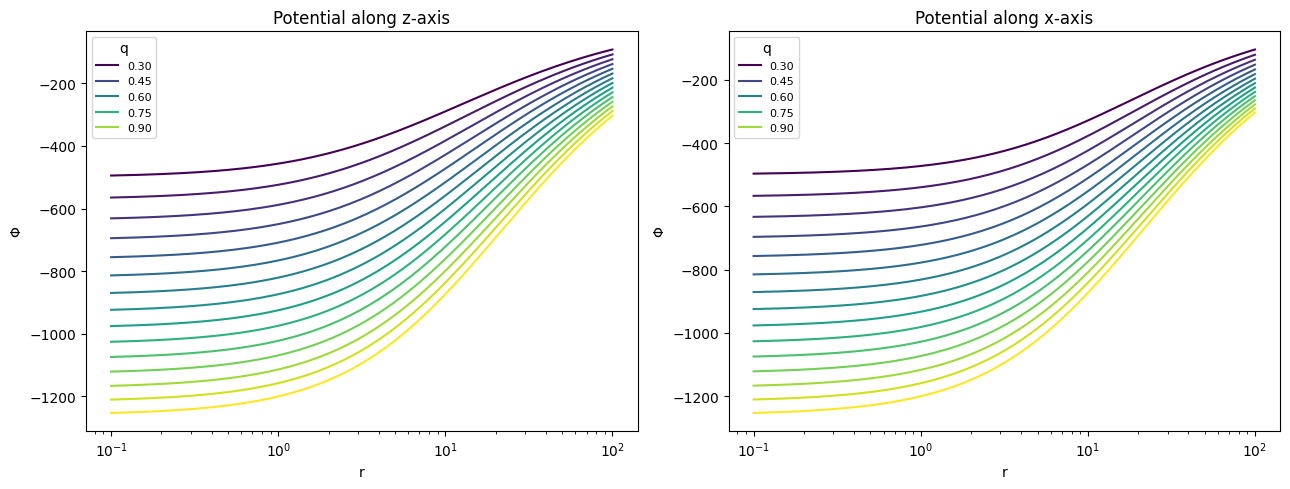

In [12]:
# Plot potential along the z-axis for each q
r_1d = jnp.logspace(-1, 2, 150)
zeros = jnp.zeros_like(r_1d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(q_values)))

for i, (q, exp) in enumerate(zip(q_values, expansions)):
    phi_z = jax.vmap(exp)(zeros, zeros, r_1d)
    phi_x = jax.vmap(exp)(r_1d, zeros, zeros)
    axes[0].semilogx(r_1d, phi_z, color=cmap[i], label=f"{q:.2f}" if i % 3 == 0 else None)
    axes[1].semilogx(r_1d, phi_x, color=cmap[i], label=f"{q:.2f}" if i % 3 == 0 else None)

axes[0].set_title("Potential along z-axis")
axes[1].set_title("Potential along x-axis")
for ax in axes:
    ax.set_xlabel("r")
    ax.set_ylabel(r"$\Phi$")
    ax.legend(title="q", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Isopotential contours for selected q values

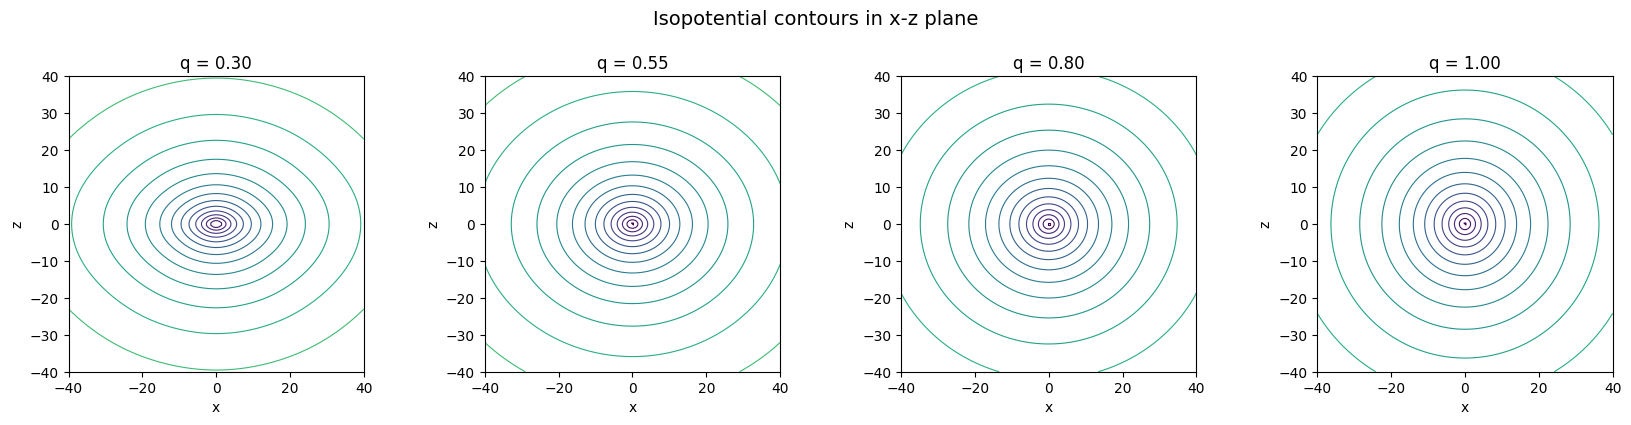

In [13]:
N = 150
lim = 40.0
x1d = jnp.linspace(-lim, lim, N)
z1d = jnp.linspace(-lim, lim, N)
X, Z = jnp.meshgrid(x1d, z1d, indexing="ij")
Y0 = jnp.zeros_like(X)

pick = [0, len(q_values)//3, 2*len(q_values)//3, -1]
fig, axes = plt.subplots(1, len(pick), figsize=(4.2*len(pick), 4))

for ax, idx in zip(axes, pick):
    phi_map = jax.vmap(jax.vmap(expansions[idx]))(X, Y0, Z)
    levels = np.linspace(float(phi_map.min()), float(phi_map.max()) * 0.05, 20)
    ax.contour(np.array(x1d), np.array(z1d), np.array(phi_map.T),
               levels=levels, cmap="viridis", linewidths=0.8)
    ax.set_title(f"q = {q_values[idx]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_aspect("equal")

fig.suptitle("Isopotential contours in x-z plane", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. `from_spheroid` — specialised path for Agama spheroids

If your density is the Agama Spheroid formula specifically:

$$\rho = \rho_0 \left(\frac{\tilde r}{a}\right)^{-\gamma}
\left[1 + \left(\frac{\tilde r}{a}\right)^\alpha\right]^{(\gamma-\beta)/\alpha}
\exp\!\left[-\left(\frac{\tilde r}{r_\mathrm{cut}}\right)^\xi\right]$$

then `from_spheroid` is even faster — it evaluates the density analytically
via vectorised array ops (no `vmap`), and the entire pipeline is a single
JIT-compiled function that never recompiles when parameters change.

In [14]:
# Warmup
_ = MultipoleExpansion.from_spheroid(
    rho0=1.0, alpha=1.0, beta=3.0, gamma=1.0, a=10.0, p=0.8, q=0.5, **grid_kw
)

# Sweep over inner slope gamma
gamma_values = np.linspace(0.5, 2.0, 20)

t0 = time.perf_counter()
spheroid_exps = []
for g in gamma_values:
    exp = MultipoleExpansion.from_spheroid(
        rho0=1.0, alpha=1.0, beta=3.0, gamma=float(g), a=10.0,
        p=0.8, q=0.5, **grid_kw,
    )
    spheroid_exps.append(exp)
t1 = time.perf_counter()
print(f"Built {len(gamma_values)} spheroid expansions in {(t1-t0)*1e3:.0f} ms "
      f"({(t1-t0)*1e3/len(gamma_values):.0f} ms each)")

Built 20 spheroid expansions in 56 ms (3 ms each)


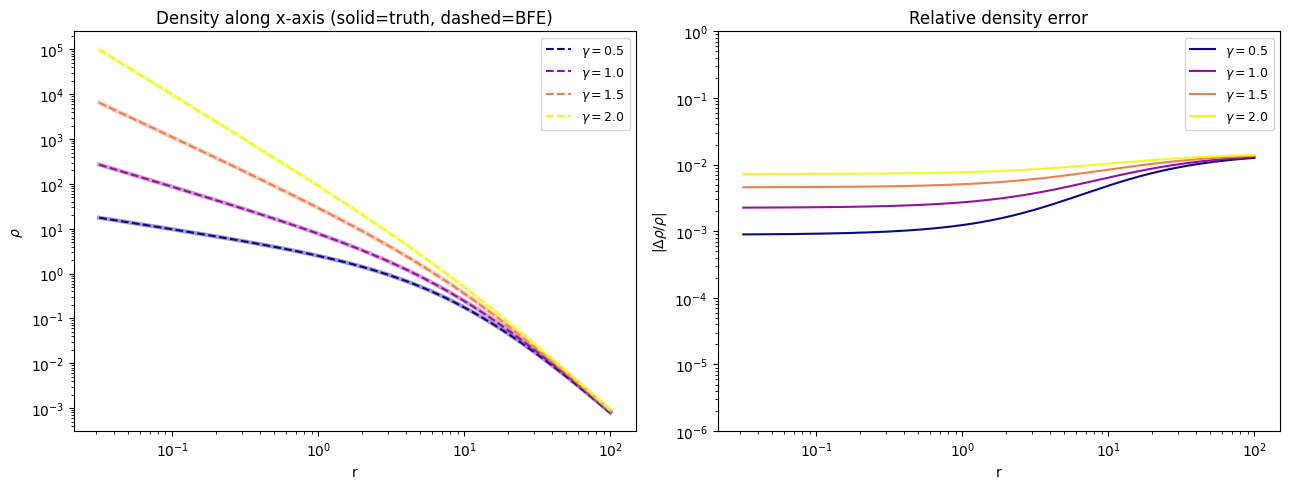

In [15]:
# Compare density profiles: truth vs reconstruction
r_1d = jnp.logspace(-1.5, 2, 200)
zeros = jnp.zeros_like(r_1d)

pick_g = [0, len(gamma_values)//3, 2*len(gamma_values)//3, -1]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap_g = plt.cm.plasma(np.linspace(0, 1, len(gamma_values)))

for idx in pick_g:
    g = gamma_values[idx]
    exp = spheroid_exps[idx]
    truth = SpheroidDensity(rho0=1.0, alpha=1.0, beta=3.0, gamma=float(g),
                           a=10.0, p=0.8, q=0.5, n_r=512, r_min=1e-3, r_max=1e4)

    rho_t = jax.vmap(truth)(r_1d, zeros, zeros)
    rho_r = jax.vmap(exp.density)(r_1d, zeros, zeros)

    axes[0].loglog(r_1d, rho_t, '-',  color=cmap_g[idx], alpha=0.4, lw=3)
    axes[0].loglog(r_1d, rho_r, '--', color=cmap_g[idx], lw=1.5,
                   label=rf"$\gamma={g:.1f}$")

    rel_err = jnp.abs(rho_r - rho_t) / (jnp.abs(rho_t) + 1e-300)
    axes[1].loglog(r_1d, rel_err, color=cmap_g[idx], label=rf"$\gamma={g:.1f}$")

axes[0].set_xlabel("r")
axes[0].set_ylabel(r"$\rho$")
axes[0].set_title("Density along x-axis (solid=truth, dashed=BFE)")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("r")
axes[1].set_ylabel(r"$|\Delta\rho/\rho|$")
axes[1].set_title("Relative density error")
axes[1].legend(fontsize=9)
axes[1].set_ylim(1e-6, 1)

plt.tight_layout()
plt.show()

## 6. Full timing comparison

Head-to-head benchmark of all build paths, with JIT fully warmed up.

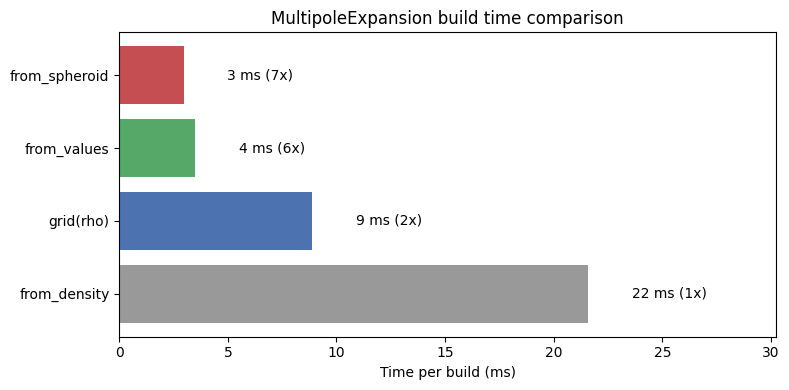

In [16]:
N_bench = 30

# from_density
t0 = time.perf_counter()
for i in range(5):
    fn = lambda x, y, z, _q=0.5+0.01*i: nfw_density(x, y, z, rs=10.0, q=_q)
    _ = MultipoleExpansion.from_density(fn, **grid_kw)
t1 = time.perf_counter()
t_fd = (t1 - t0) / 5

# grid(rho)
t0 = time.perf_counter()
for i in range(N_bench):
    fn = lambda x, y, z, _q=0.5+0.01*i: nfw_density(x, y, z, rs=10.0, q=_q)
    _ = grid(fn)
t1 = time.perf_counter()
t_gr = (t1 - t0) / N_bench

# from_values (density pre-evaluated)
rho_arrs = [
    nfw_density(grid.x, grid.y, grid.z, rs=10.0, q=0.5+0.01*i)
    for i in range(N_bench)
]
t0 = time.perf_counter()
for arr in rho_arrs:
    _ = grid.from_values(arr)
t1 = time.perf_counter()
t_fv = (t1 - t0) / N_bench

# from_spheroid
t0 = time.perf_counter()
for i in range(N_bench):
    _ = MultipoleExpansion.from_spheroid(
        rho0=1.0, alpha=1.0, beta=3.0, gamma=1.0, a=10.0,
        p=0.8, q=0.5+0.01*i, **grid_kw,
    )
t1 = time.perf_counter()
t_sp = (t1 - t0) / N_bench

methods = ["from_density", "grid(rho)", "from_values", "from_spheroid"]
times   = [t_fd, t_gr, t_fv, t_sp]
colors  = ["#999999", "#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(methods, [t*1e3 for t in times], color=colors)
ax.set_xlabel("Time per build (ms)")
ax.set_title("MultipoleExpansion build time comparison")

for bar, t in zip(bars, times):
    speedup = t_fd / t
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{t*1e3:.0f} ms ({speedup:.0f}x)",
            va="center", fontsize=10)

ax.set_xlim(0, max(times)*1e3 * 1.4)
plt.tight_layout()
plt.show()

## Summary

**Use `from_density`** for one-off builds with arbitrary density functions.

**Use `ExpansionGrid`** when you need to build many expansions:
- `grid(rho)` — convenient, works with any callable
- `grid.from_values(arr)` — fastest, you evaluate density yourself  
  (`grid.x`, `grid.y`, `grid.z` give you the evaluation points)

**Use `from_spheroid`** when your density is the Agama Spheroid formula —
it fuses density evaluation + build into one JIT-compiled kernel.

All three methods produce identical `MultipoleExpansion` objects with
`.density()`, `.__call__()` (potential), and `.acceleration()`.